#AlexNet 발표 코드

In [ ]:
import torch                                 # PyTorch 기본 라이브러리
import torch.nn as nn                        # 신경망 레이어들 (Conv, Linear 등)
import torch.optim as optim                  # 옵티마이저 (SGD, Adam 등)
import torchvision.transforms as transforms  # 이미지 전처리
from torch.utils.data import DataLoader      # 데이터 배치 로딩

#시각화
import matplotlib.pyplot as plt              # 그래프 그리기
from tqdm import tqdm  # 로딩바

In [ ]:
# 데이터 전처리

# 데이터가 원본을 그대로 학습하지 못하게 구기고, 자르고 뒤집는 과정
transform_train = transforms.Compose([  # Compose = 전처리 계획표(누가 부르면 아래 순서대로 전처리 하시오)
    transforms.Resize(256),             # 이미지를 256x256으로 리사이즈
    transforms.RandomCrop(224),         # 전체 256에서 224x224를 랜덤하게 잘라냄
    transforms.RandomHorizontalFlip(),  # 좌우 반전 (데이터 증강)
    # 추가로 논문에선 임의로 이미지의 RGB 채널 강도도 변경함(색바꿈)

    transforms.ToTensor(),            # 이미지를 텐서로 변환 (0~255 → 0~1)
    transforms.Normalize(             # 픽셀 평균값을 뺌
        mean=[0.485, 0.456, 0.406],   # RGB 각 채널의 평균값을 뺌
        std=[1.0, 1.0, 1.0]           # R, G, B 채널 각각 std=1.0 (1이라 의미 없음)
    ),
])

# 테스트 데이터는 리사이즈 외엔 변형 안함
transform_test = transforms.Compose([
    transforms.Resize(256),           # 256x256으로 리사이즈
    transforms.ToTensor(),            # 텐서로 변환
])

In [ ]:
# 데이터 가져오기
train_dataset = datasets.ImageNet(
    root='./data',               # 데이터를 저장할 폴더 경로
    split='train',               # train셋과 val셋 중 train셋을 선택
    transform=transform_train)   # 위에서 정의한 전처리(계획표)를 적용

test_dataset  = datasets.ImageNet(
    root='./data',
    split='val',                 # train셋과 val셋 중 val셋을 선택
    transform=transform_test)

# 데이터파이프라인 : 데이터를 모델에 넣어주는 데이터 로더 과정
train_loader = DataLoader(train_dataset,  # 위에서 정의한 전처리가 끝난 데이터셋을 사용
                          batch_size=128, # 한 번에 128장씩 묶어서 불러옴
                          shuffle=True,   # 매 epoch마다 데이터 순서를 섞음(순서 외우기 방지)
                          num_workers=4)  # gpu가 학습할 때 4개의 프로세스가 사진을 가져와 대기시킴
                                          # >> 대기하고 있으니까 대기시간 없이 빠른 학습

test_loader  = DataLoader(test_dataset,
                          batch_size=128,
                          shuffle=False,
                          num_workers=4)

###논문 코드 구현 시각화  
1. 사진 한장을 양쪽의 gpu로 보냄  
2. conv1 과 conv2를 통과하면서 각각 48 >> 128개의 커널 출력(총 256채널)  
  
3. 두 gpu 결과물 모아서 conv3에 투입(정보 공유) 및 384개의 커널 출력
  
4. 다시 두 gpu로 나눠 conv4, conv5에 투입 커널은 conv4에선 384개 그대로, conv 5에선 256(각각 128)개로 감소
  
### 총 256채널짜리 데이터가 다시 만나서 FC1으로 들어감


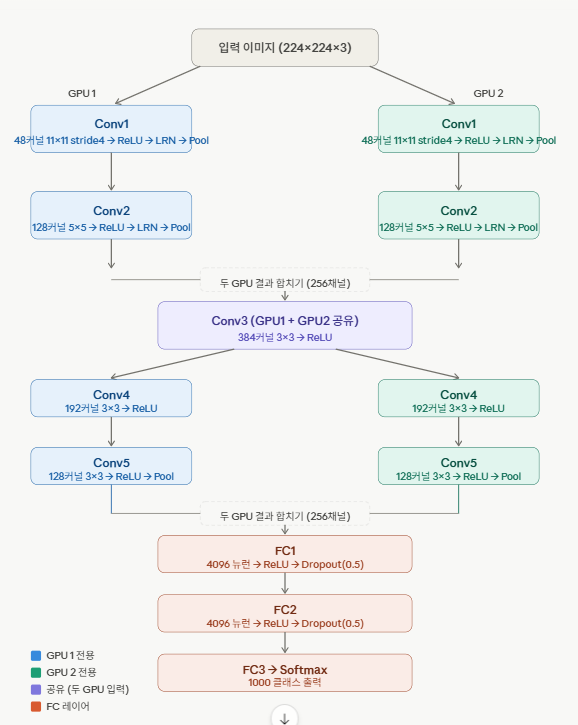

###논문 코드 구현

```
class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        # ── GPU1 전용 ──────────────────────────────
        self.conv1_gpu1 = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=11, stride=4),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.conv2_gpu1 = nn.Sequential(
            nn.Conv2d(48, 128, kernel_size=5),  # 같은 GPU(48채널)만 입력
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── GPU2 전용 ──────────────────────────────
        self.conv1_gpu2 = nn.Sequential(
            nn.Conv2d(3, 48, kernel_size=11, stride=4),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.conv2_gpu2 = nn.Sequential(
            nn.Conv2d(48, 128, kernel_size=5),  # 같은 GPU(48채널)만 입력
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── Conv3: 두 GPU 결과 합쳐서 입력 (256채널) ──
        self.conv3_gpu1 = nn.Sequential(
            nn.Conv2d(256, 192, kernel_size=3),
            nn.ReLU(),
        )
        self.conv3_gpu2 = nn.Sequential(
            nn.Conv2d(256, 192, kernel_size=3),
            nn.ReLU(),
        )

        # ── Conv4, Conv5: 같은 GPU 내에서만 연결 ──────
        self.conv4_gpu1 = nn.Sequential(
            nn.Conv2d(192, 192, kernel_size=3),
            nn.ReLU(),
        )
        self.conv4_gpu2 = nn.Sequential(
            nn.Conv2d(192, 192, kernel_size=3),
            nn.ReLU(),
        )

        self.conv5_gpu1 = nn.Sequential(
            nn.Conv2d(192, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.conv5_gpu2 = nn.Sequential(
            nn.Conv2d(192, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── FC: 두 GPU 결과 합쳐서 입력 ───────────────
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        # Conv1 (각 GPU 독립)
        x1 = self.conv1_gpu1(x.to('cuda:0'))
        x2 = self.conv1_gpu2(x.to('cuda:1'))

        # Conv2 (같은 GPU 내에서만)
        x1 = self.conv2_gpu1(x1)
        x2 = self.conv2_gpu2(x2)

        # Conv3 (두 GPU 결과 합쳐서 입력)
        x_merged = torch.cat([x1, x2.to('cuda:0')], dim=1)  # 256채널
        x1 = self.conv3_gpu1(x_merged)
        x2 = self.conv3_gpu2(x_merged.to('cuda:1'))

        # Conv4 (같은 GPU 내에서만)
        x1 = self.conv4_gpu1(x1)
        x2 = self.conv4_gpu2(x2)

        # Conv5 (같은 GPU 내에서만)
        x1 = self.conv5_gpu1(x1)
        x2 = self.conv5_gpu2(x2)

        # FC (두 GPU 결과 합치기)
        x = torch.cat([x1, x2.to('cuda:0')], dim=1)  # 256채널
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
        ```

In [ ]:
# 지금은 그래픽카드 용량에 부하가 업으니 굳이 나누지 않고 한번에 사용

class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
                                         # 시퀀셜은 계획표 누가 부르면 아래 적어둔대로 해
        self.features = nn.Sequential(   # 특징 분석 계획표
            # Conv1
            nn.Conv2d(3, 96, kernel_size=11, stride=4), # 입력, 출력, conv 크기, 이동거리
            nn.ReLU(), # 비선형성 + 기울기 소멸 방지
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2), # 현재는 batchnorm으로 대체
            nn.MaxPool2d(kernel_size=3, stride=2), #커널 크기 3 짜리 conv로 2칸씩 건너 다니며 압축

            # Conv2
            nn.Conv2d(96, 256, kernel_size=5),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2), # LRN은 conv2 까지만
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(256, 384, kernel_size=3),
            nn.ReLU(),

            # Conv4
            nn.Conv2d(384, 384, kernel_size=3),
            nn.ReLU(),

            # Conv5
            nn.Conv2d(384, 256, kernel_size=3), # 커널크기 256으로 감소
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # 이 사이에 1열로 쭉 펴는 단계가 있음(실제 코드는 foward에)

        self.classifier = nn.Sequential(  # 분석 및 추리 계획표
            nn.Dropout(0.5),              # 과적합 방지
            nn.Linear(256 * 6 * 6, 4096), # 쫙 펴진 데이터 읽고 분석
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, num_classes), # 최종 분류 갯수 1000개, 각각 확률로 출력
        )

    def forward(self, x): #각 계획표들의 실행 순서
        x = self.features(x)        # 1. 특징분석 계획표 먼저 순서대로 실행하고
        x = x.view(x.size(0), -1)   # 2. 일자로 쫙 펴서
        x = self.classifier(x)      # 3. 추리 계획표 순서대로 진행시켜
        return x

LRN 하이퍼파라미터  

size: 주변 커널(n)장을 보고, 주변 커널들이 강하게 반응하고 있으면, 나도 덩달아 강하게 반응하지 말고 좀 줄여라

a(알파): 크게 설정할 수록 억제 강력해짐(선형)

b(베타): 크게 설정할 수록 급격하게 억제(비선형)

k: 식에 나누기가 들어감(분모에 k) >> 0이 되지 않도록 설정

In [1]:
# 손실함수 / 옵티마이저
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # gpu사용 가능
model     = AlexNet(num_classes=1000).to(device)  # gpu에 올린 알렉스넷을 model객체로 만듦

criterion = nn.CrossEntropyLoss() # 손실함수: CrossEntropy를 사용함(분류문제)

optimizer = optim.SGD(      # 업데이트 가이드
    model.parameters(),     # 학습할 파라미터 (모든 가중치)
    lr=0.01, momentum=0.9,  # 학습률, 모멘텀(관성)
    weight_decay=0.0005)    # 가중치 감쇠(높을수록 더 뺌,과적합 방지)

scheduler = optim.lr_scheduler.ReduceLROnPlateau( # 학습률을 자동으로 줄여줌
    optimizer,  # 조절할 옵티마이저
    mode='min', # 손실값이 줄어드는 방향으로 모니터링
    factor=0.1, # lr을 10분의 1로 줄임
    patience=5) # 5 epoch 동안 개선 없으면 lr 감소

NameError: name 'torch' is not defined

In [ ]:
# 학습 : 앞에서 만들어놓은 가이드와 계획표를 실행하는 파트
def train(model, loader, criterion, optimizer, device):
    model.train()   # 모델 학습
    total_loss = 0  # 오차 업데이트
    for images, labels in loader:   # train_loader를 자동으로 불러옴
        images, labels = images.to(device), labels.to(device) # gpu로 보냄
        optimizer.zero_grad()   # 기울기 초기화
        outputs = model(images) # 모델(알렉스넷)에 image를 넣어 나온 결과를 output 객체에 담음
        loss    = criterion(outputs, labels)    # 결과와 정답(라벨)의 오차를 loss 객체에 담음
        loss.backward()   # 오차(loss)를 뒤에서 앞으로(FC ~ conv1)전달, 역전파
        optimizer.step()  # 옵티마이저(업데이트) 시작
        total_loss += loss.item()
    return total_loss / len(loader)   # 배치 평균 손실 반

In [ ]:
# 평가 (논문: 5개 코너 + 중앙 + 각각 수평반전 = 10개 패치 평균)
def evaluate(model, loader, device):
    model.eval()      # 드롭아웃 등 학습 전용 기능을 끔
    correct_top1 = 0  # top-1 맞은 개수
    correct_top5 = 0  # top-5 맞은 개수
    total        = 0  # 전체 이미지 수

    with torch.no_grad(): # 평가할 땐 기울기 계산 안함
        for images, labels in tqdm(loader, desc='평가 중'):
            labels     = labels.to(device)
            batch_size = images.size(0) # 배치 크기

            # 테스트 전저리
            # 모델 입력크기 224, 이미지 256이므로 10군데를 잘라서 평균내면 더 안정적 예측
            crops = []
            for img in images:
                c, h, w = img.shape
                patches = [
                    img[:, 0:224, 0:224],   # 좌상
                    img[:, 0:224, w-224:w],   # 우상
                    img[:, h-224:h, 0:224],   # 좌하
                    img[:, h-224:h, w-224:w], # 우하
                    img[:, (h-224)//2:(h+224)//2, (w-224)//2:(w+224)//2], # 중앙
                ]
                patches += [torch.flip(p, dims=[2]) for p in patches] # 수평반전 5개 추가
                crops.append(torch.stack(patches))

            crops   = torch.stack(crops).to(device)   # (batch, 10, C, H, W)
            crops   = crops.view(-1, 3, 224, 224)     # (batch*10, C, H, W)

            # 실제 평가 시작
            outputs = model(crops)    # 모델에 넣기
            outputs = outputs.view(batch_size, 10, -1).mean(dim=1)  # 10개 평균

            _, predicted = outputs.max(1)   # 가장 높은 확률 1개 선택 (top-1)
            correct_top1 += predicted.eq(labels).sum().item() # 정답과 비교해서 맞은 개수 누적

            _, top5 = outputs.topk(5, dim=1)    # 가장 높은 확률 5개 선택 (top-5)
            correct_top5 += top5.eq(labels.view(-1, 1).expand_as(top5)).sum().item()
                                                # 정답이 5개 안에 있으면 맞은 것으로 처리

            total += labels.size(0)   # 전체 이미지 수 누적

    return correct_top1 / total, correct_top5 / total   # top-1, top-5 정확도 반환

In [ ]:
# 실행 (논문: 90 epoch)
train_losses = []
top1_accs    = []
top5_accs    = []

for epoch in range(90):
    train_loss         = train(model, train_loader, criterion, optimizer, device)
    top1_acc, top5_acc = evaluate(model, test_loader, device)
    scheduler.step(train_loss)

    train_losses.append(train_loss)
    top1_accs.append(top1_acc)
    top5_accs.append(top5_acc)

    print(f"Epoch {epoch+1:3d} | "
          f"train loss: {train_loss:.4f} | "
          f"top-1: {top1_acc*100:.2f}% | "
          f"top-5: {top5_acc*100:.2f}%")


In [ ]:
# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('train loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')

ax2.plot(top1_accs, label='top-1')
ax2.plot(top5_accs, label='top-5')
ax2.set_title('accuracy')
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.legend()

plt.tight_layout()
plt.show()